In [173]:
# ── CONFIG ────────────────────────────────────────────────────────────────────
INSTANCE_PATH = "instance12"   # folder containing the 3 CSVs
OUTPUT_CSV    = "result.csv"   # where to write the solution

# R&R hyper-parameters
N_ITERATIONS   = 3000          # total R&R iterations
F_RADIAL       = 0.25          # fraction of orders destroyed (radial ruin)
F_RANDOM       = 0.20          # fraction of orders destroyed (random ruin)
RUIN_MIX       = 0.5           # probability of choosing radial vs random
MAX_STACK      = 4             # max deliveries per route
MAX_ROUTE_MIN  = 180           # max route duration (minutes)
T0_SCALE       = 0.5           # initial threshold = T0_SCALE * std(obj, random walk)
HALF_LIFE      = 0.15          # exponential cooling half-life
RANDOM_SEED    = 42
# ─────────────────────────────────────────────────────────────────────────────

In [174]:
import os, random, math, copy, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from collections import defaultdict

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
print("Libraries loaded ✓")

Libraries loaded ✓


In [175]:
import glob

def _find_col(df, *candidates):
    """Return the first column name that exists in df (case-insensitive, strip)."""
    normalised = {c.strip().lower(): c for c in df.columns}
    for cand in candidates:
        if cand.strip().lower() in normalised:
            return normalised[cand.strip().lower()]
    raise KeyError(f"None of {candidates} found in columns: {list(df.columns)}")

def _find_file(folder, keyword):
    """
    Find the first CSV whose filename contains *keyword* (case-insensitive).
    Works regardless of spaces, version suffixes like ' (2) (2)', etc.
    """
    all_csvs = glob.glob(os.path.join(folder, '**', '*.csv'), recursive=True)
    matches  = [f for f in all_csvs
                if keyword.lower() in os.path.basename(f).lower()]
    if not matches:
        raise FileNotFoundError(
            f"No CSV containing '{keyword}' found under '{folder}'.\n"
            f"All CSVs found: {all_csvs}")
    return sorted(matches)[0]

def load_instance(path):
    couriers_file    = _find_file(path, 'courier')
    deliveries_file  = _find_file(path, 'deliver')
    traveltimes_file = _find_file(path, 'travel')

    print('Files detected:')
    print(f'  couriers    -> {couriers_file}')
    print(f'  deliveries  -> {deliveries_file}')
    print(f'  traveltimes -> {traveltimes_file}')

    couriers_df   = pd.read_csv(couriers_file)
    deliveries_df = pd.read_csv(deliveries_file)
    tt_df         = pd.read_csv(traveltimes_file, index_col=0)

    print('\ncouriers columns  :', list(couriers_df.columns))
    print('deliveries columns:', list(deliveries_df.columns))
    print('traveltimes index :', tt_df.index.name,
          '| sample cols:', list(tt_df.columns[:5]))

    # ── Couriers ──────────────────────────────────────────────────────────────
    col_cid  = _find_col(couriers_df, 'ID')
    col_cloc = _find_col(couriers_df, 'Location')
    col_ccap = _find_col(couriers_df, 'Capacity')

    couriers = {}
    for _, row in couriers_df.iterrows():
        couriers[int(row[col_cid])] = {
            'id'      : int(row[col_cid]),
            'location': int(row[col_cloc]),
            'capacity': float(row[col_ccap]),
        }

    # ── Deliveries ────────────────────────────────────────────────────────────
    col_did   = _find_col(deliveries_df, 'ID')
    col_dcap  = _find_col(deliveries_df, 'Capacity')
    col_ploc  = _find_col(deliveries_df, 'Pickup Loc', 'Pickup_Loc')
    col_tws   = _find_col(deliveries_df, 'Time Window Start', 'Time_Window_Start')
    col_stack = _find_col(deliveries_df,
                          'Pickup Stacking_Id', 'Pickup Stacking Id',
                          'Pickup_Stacking_Id', 'PickupStackingId',
                          'Pickup Stacking Id')
    col_dloc  = _find_col(deliveries_df, 'Dropoff Loc', 'Dropoff_Loc')

    deliveries = {}
    for _, row in deliveries_df.iterrows():
        deliveries[int(row[col_did])] = {
            'id'         : int(row[col_did]),
            'capacity'   : float(row[col_dcap]),
            'pickup_loc' : int(row[col_ploc]),
            'tw_start'   : float(row[col_tws]),
            'stack_id'   : row[col_stack],
            'dropoff_loc': int(row[col_dloc]),
        }

    # ── Travel-time matrix ────────────────────────────────────────────────────
    tt_df.columns = [int(c) for c in tt_df.columns]
    tt_df.index   = [int(i) for i in tt_df.index]
    travel = tt_df.to_dict()

    def T(a, b):
        try:
            return float(travel[b][a])
        except KeyError:
            return float(travel[a][b])   # symmetric fallback

    print(f'\nLoaded: {len(couriers)} couriers, {len(deliveries)} deliveries, '
          f'{len(tt_df)} locations')
    return couriers, deliveries, T

couriers, deliveries, T = load_instance(INSTANCE_PATH)
ORDER_IDS = list(deliveries.keys())

Files detected:
  couriers    -> instance12\couriers (11).csv
  deliveries  -> instance12\deliveries (11).csv
  traveltimes -> instance12\traveltimes (11).csv

couriers columns  : ['ID', 'Location', 'Capacity']
deliveries columns: ['ID', 'Capacity', 'Pickup Loc', 'Time Window Start', 'Pickup Stacking_Id', 'Dropoff Loc']
traveltimes index : Locations | sample cols: ['1', '2', '3', '4', '5']

Loaded: 6 couriers, 5 deliveries, 13 locations


In [176]:
# A solution is a dict  courier_id -> list-of-order-ids  (assignment only).
# The actual visit sequence is derived during evaluation.

# ── Route evaluator ───────────────────────────────────────────────────────────
def evaluate_route(courier_id, order_ids, couriers, deliveries, T):
    """
    Build the best feasible visit sequence for a courier given its assigned orders.
    Returns (total_delivery_time, route_duration, visit_sequence, feasible).
    Uses a greedy nearest-feasible construction.
    """
    if not order_ids:
        return 0.0, 0.0, [], True

    c       = couriers[courier_id]
    cap_max = c["capacity"]
    depot   = c["location"]

    # Nodes: (order_id, 'p') = pickup,  (order_id, 'd') = dropoff
    unvisited_pickups  = set(order_ids)
    unvisited_dropoffs = set()
    sequence           = []
    current_loc        = depot
    current_time       = 0.0
    current_load       = 0.0
    total_delivery_t   = 0.0

    while unvisited_pickups or unvisited_dropoffs:
        candidates = []

        # Dropoffs first if at capacity
        if current_load >= cap_max and unvisited_dropoffs:
            for oid in unvisited_dropoffs:
                dl  = deliveries[oid]["dropoff_loc"]
                arr = current_time + T(current_loc, dl)
                candidates.append((arr, oid, "d", dl))
        else:
            # Pickups (respect time-window and stack limit)
            for oid in unvisited_pickups:
                d   = deliveries[oid]
                pl  = d["pickup_loc"]
                arr = current_time + T(current_loc, pl)
                svc = max(arr, d["tw_start"])   # wait if early
                if current_load + d["capacity"] <= cap_max:
                    candidates.append((svc, oid, "p", pl))
            # Dropoffs always eligible
            for oid in unvisited_dropoffs:
                dl  = deliveries[oid]["dropoff_loc"]
                arr = current_time + T(current_loc, dl)
                candidates.append((arr, oid, "d", dl))

        if not candidates:
            return float("inf"), float("inf"), sequence, False

        # Greedy: choose earliest feasible
        candidates.sort(key=lambda x: x[0])
        chosen_time, chosen_id, chosen_type, chosen_loc = candidates[0]

        current_time = chosen_time
        current_loc  = chosen_loc
        sequence.append((chosen_id, chosen_type))

        if chosen_type == "p":
            current_load += deliveries[chosen_id]["capacity"]
            unvisited_pickups.discard(chosen_id)
            unvisited_dropoffs.add(chosen_id)
        else:
            current_load -= deliveries[chosen_id]["capacity"]
            unvisited_dropoffs.discard(chosen_id)
            total_delivery_t += current_time

    route_duration = current_time + T(current_loc, depot)
    feasible = (route_duration <= MAX_ROUTE_MIN and
                len(order_ids) <= MAX_STACK)
    return total_delivery_t, route_duration, sequence, feasible


def objective(solution, couriers, deliveries, T):
    """Sum of delivery times across all couriers."""
    total = 0.0
    for cid, orders in solution.items():
        dt, dur, seq, ok = evaluate_route(cid, orders, couriers, deliveries, T)
        if not ok and orders:
            total += 1e9   # heavy penalty for infeasible routes
        else:
            total += dt
    return total

print("Route evaluator defined ✓")

Route evaluator defined ✓


In [177]:
def build_initial_solution(couriers, deliveries, T):
    """
    Greedily insert each order into the best available courier slot.
    Returns a feasible solution dict.
    """
    solution = {cid: [] for cid in couriers}
    order_list = list(deliveries.keys())
    random.shuffle(order_list)

    for oid in order_list:
        best_cid  = None
        best_cost = float("inf")

        for cid in couriers:
            current = solution[cid]
            if len(current) >= MAX_STACK:
                continue
            candidate = current + [oid]
            dt, dur, _, ok = evaluate_route(cid, candidate, couriers, deliveries, T)
            if ok and dt < best_cost:
                best_cost = dt
                best_cid  = cid

        if best_cid is None:
            # Force-assign to least-loaded courier (may be infeasible)
            best_cid = min(couriers, key=lambda c: len(solution[c]))

        solution[best_cid].append(oid)

    return solution


print("Building initial solution...")
t0 = time.time()
initial_solution = build_initial_solution(couriers, deliveries, T)
init_obj = objective(initial_solution, couriers, deliveries, T)
print(f"Initial objective (sum of delivery times): {init_obj:.2f}  "
      f"[{time.time()-t0:.1f}s]")

Building initial solution...
Initial objective (sum of delivery times): 78.00  [0.0s]


In [178]:
# ── Ruin operators ────────────────────────────────────────────────────────────

def radial_ruin(solution, deliveries, T, f=F_RADIAL):
    """Remove a spatially clustered set of orders."""
    all_orders = [oid for orders in solution.values() for oid in orders]
    if not all_orders:
        return solution, []

    n_remove = max(1, int(f * len(all_orders)))
    center   = random.choice(all_orders)
    center_loc = deliveries[center]["pickup_loc"]

    # Sort all orders by travel-time from the centre pickup
    sorted_orders = sorted(
        all_orders,
        key=lambda o: T(center_loc, deliveries[o]["pickup_loc"])
    )
    to_remove = set(sorted_orders[:n_remove])

    new_sol = {cid: [o for o in orders if o not in to_remove]
               for cid, orders in solution.items()}
    return new_sol, list(to_remove)


def random_ruin(solution, deliveries, T, f=F_RANDOM):
    """Remove a random subset of orders."""
    all_orders = [oid for orders in solution.values() for oid in orders]
    if not all_orders:
        return solution, []

    n_remove  = max(1, int(f * len(all_orders)))
    to_remove = set(random.sample(all_orders, min(n_remove, len(all_orders))))

    new_sol = {cid: [o for o in orders if o not in to_remove]
               for cid, orders in solution.items()}
    return new_sol, list(to_remove)


# ── Recreate operator (best-insertion) ───────────────────────────────────────

def best_insertion_recreate(partial_sol, unassigned, couriers, deliveries, T):
    """Re-insert unassigned orders one-by-one using best-insertion."""
    sol = copy.deepcopy(partial_sol)
    unassigned = list(unassigned)
    random.shuffle(unassigned)

    for oid in unassigned:
        best_cid  = None
        best_cost = float("inf")

        for cid in couriers:
            if len(sol[cid]) >= MAX_STACK:
                continue
            candidate = sol[cid] + [oid]
            dt, dur, _, ok = evaluate_route(cid, candidate, couriers, deliveries, T)
            if ok and dt < best_cost:
                best_cost = dt
                best_cid  = cid

        if best_cid is None:
            best_cid = min(couriers, key=lambda c: len(sol[c]))
        sol[best_cid].append(oid)

    return sol


print("Ruin & Recreate operators defined ✓")

Ruin & Recreate operators defined ✓


In [179]:
def threshold_schedule(x, T0, half_life=HALF_LIFE):
    """Exponential decay: T = T0 * exp(-ln2 * x / half_life)"""
    return T0 * math.exp(-math.log(2) * x / half_life)


def calibrate_T0(solution, n_samples=200):
    """Estimate T0 from the std of objective changes in a short random walk."""
    deltas = []
    cur    = copy.deepcopy(solution)
    cur_obj = objective(cur, couriers, deliveries, T)
    for _ in range(n_samples):
        if random.random() < RUIN_MIX:
            partial, bag = radial_ruin(cur, deliveries, T)
        else:
            partial, bag = random_ruin(cur, deliveries, T)
        new = best_insertion_recreate(partial, bag, couriers, deliveries, T)
        new_obj = objective(new, couriers, deliveries, T)
        deltas.append(abs(new_obj - cur_obj))
        cur, cur_obj = new, new_obj
    return T0_SCALE * float(np.std(deltas)) if deltas else 1.0


def ruin_and_recreate(initial_solution, n_iter=N_ITERATIONS):
    print("Calibrating T₀ ...")
    T0 = calibrate_T0(initial_solution)
    print(f"T₀ = {T0:.4f}")

    current      = copy.deepcopy(initial_solution)
    current_obj  = objective(current, couriers, deliveries, T)
    best         = copy.deepcopy(current)
    best_obj     = current_obj

    history_obj  = [current_obj]
    history_best = [best_obj]
    history_temp = [T0]
    accepted_iter = []
    improved_iter = []

    print(f"Starting R&R optimisation ({n_iter} iterations)...")
    t_start = time.time()

    for i in range(1, n_iter + 1):
        x   = i / n_iter                       # schedule variable 0→1
        th  = threshold_schedule(x, T0)        # current threshold

        # ── Ruin ──────────────────────────────────────────────────────────────
        if random.random() < RUIN_MIX:
            partial, bag = radial_ruin(current, deliveries, T)
        else:
            partial, bag = random_ruin(current, deliveries, T)

        # ── Recreate ──────────────────────────────────────────────────────────
        candidate     = best_insertion_recreate(partial, bag, couriers, deliveries, T)
        candidate_obj = objective(candidate, couriers, deliveries, T)

        # ── Threshold Accepting ───────────────────────────────────────────────
        delta = candidate_obj - current_obj
        if delta <= th:                        # accept if not much worse
            current     = candidate
            current_obj = candidate_obj
            accepted_iter.append(i)

        if current_obj < best_obj:
            best     = copy.deepcopy(current)
            best_obj = current_obj
            improved_iter.append(i)

        history_obj.append(current_obj)
        history_best.append(best_obj)
        history_temp.append(th)

        if i % (n_iter // 10) == 0:
            elapsed = time.time() - t_start
            print(f"  iter {i:5d}/{n_iter}  "
                  f"current={current_obj:.1f}  best={best_obj:.1f}  "
                  f"threshold={th:.4f}  [{elapsed:.1f}s]")

    print(f"\nOptimisation complete. Best objective = {best_obj:.2f}")
    return best, best_obj, {
        "obj"     : history_obj,
        "best"    : history_best,
        "temp"    : history_temp,
        "accepted": accepted_iter,
        "improved": improved_iter,
        "T0"      : T0,
    }


best_solution, best_obj, history = ruin_and_recreate(initial_solution)

Calibrating T₀ ...
T₀ = 0.0000
Starting R&R optimisation (3000 iterations)...
  iter   300/3000  current=78.0  best=78.0  threshold=0.0000  [0.0s]
  iter   600/3000  current=78.0  best=78.0  threshold=0.0000  [0.1s]
  iter   900/3000  current=78.0  best=78.0  threshold=0.0000  [0.2s]
  iter  1200/3000  current=78.0  best=78.0  threshold=0.0000  [0.2s]
  iter  1500/3000  current=78.0  best=78.0  threshold=0.0000  [0.3s]
  iter  1800/3000  current=78.0  best=78.0  threshold=0.0000  [0.3s]
  iter  2100/3000  current=78.0  best=78.0  threshold=0.0000  [0.4s]
  iter  2400/3000  current=78.0  best=78.0  threshold=0.0000  [0.4s]
  iter  2700/3000  current=78.0  best=78.0  threshold=0.0000  [0.5s]
  iter  3000/3000  current=78.0  best=78.0  threshold=0.0000  [0.5s]

Optimisation complete. Best objective = 78.00


In [180]:
def write_result(solution, couriers, deliveries, T, path):
    rows = []
    for cid in sorted(couriers):
        orders = solution.get(cid, [])
        _, _, seq, _ = evaluate_route(cid, orders, couriers, deliveries, T)
        visit_ids = [oid for oid, _ in seq]
        row = [cid] + visit_ids
        rows.append(row)

    max_cols = max(len(r) for r in rows) if rows else 1
    padded = [r + [""] * (max_cols - len(r)) for r in rows]
    cols   = ["ID"] + [f"stop_{i}" for i in range(1, max_cols)]
    df     = pd.DataFrame(padded, columns=cols)
    df.to_csv(path, index=False)
    print(f"Result written to {path}")

write_result(best_solution, couriers, deliveries, T, OUTPUT_CSV)

# Quick feasibility summary
feasible_routes = 0
for cid, orders in best_solution.items():
    _, dur, _, ok = evaluate_route(cid, orders, couriers, deliveries, T)
    if ok or not orders:
        feasible_routes += 1

print(f"Feasible routes: {feasible_routes}/{len(couriers)}")
print(f"Total sum of delivery times (T_min): {best_obj:.2f} minutes")

Result written to result.csv
Feasible routes: 6/6
Total sum of delivery times (T_min): 78.00 minutes


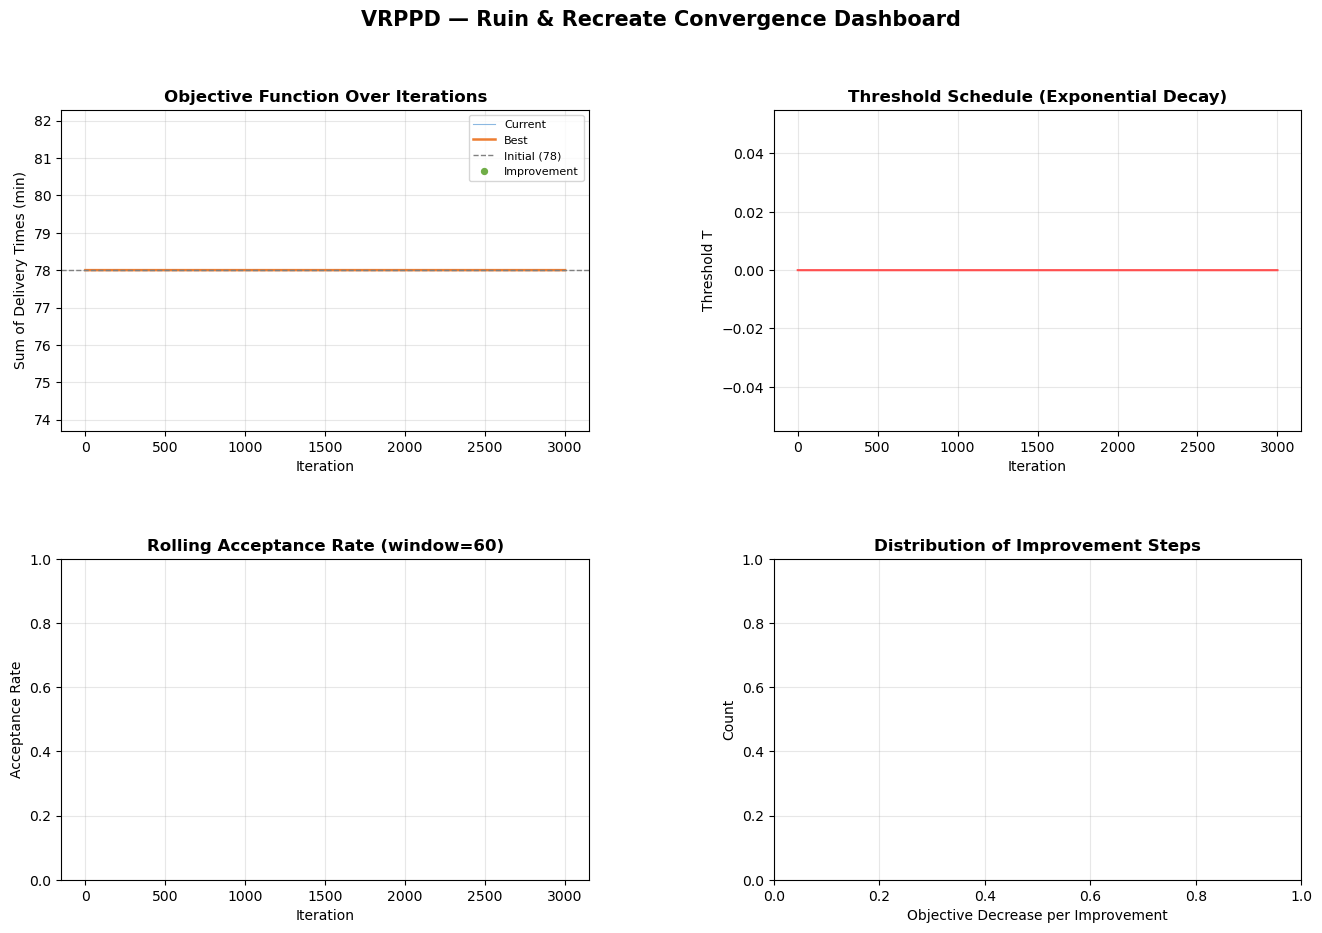

Figure 1 saved: convergence_dashboard.png


In [181]:
# ─── Figure 1: Convergence dashboard (2×2) ────────────────────────────────────
fig = plt.figure(figsize=(16, 10))
fig.suptitle("VRPPD — Ruin & Recreate Convergence Dashboard",
             fontsize=15, fontweight="bold", y=0.98)
gs  = GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

iters = range(len(history["obj"]))

# ── Panel A: objective over time ──────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(iters, history["obj"],  color="#5B9BD5", lw=0.8, alpha=0.7, label="Current")
ax1.plot(iters, history["best"], color="#ED7D31", lw=1.8, label="Best")
ax1.axhline(init_obj, color="grey", ls="--", lw=1, label=f"Initial ({init_obj:.0f})")
ax1.scatter(history["improved"],
            [history["best"][i] for i in history["improved"]],
            color="#70AD47", s=18, zorder=5, label="Improvement")
ax1.set_title("Objective Function Over Iterations", fontweight="bold")
ax1.set_xlabel("Iteration")
ax1.set_ylabel("Sum of Delivery Times (min)")
ax1.legend(fontsize=8)
ax1.grid(alpha=0.3)

# ── Panel B: threshold schedule ───────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(iters, history["temp"], color="#FF5050", lw=1.5)
ax2.fill_between(iters, history["temp"], alpha=0.15, color="#FF5050")
ax2.set_title("Threshold Schedule (Exponential Decay)", fontweight="bold")
ax2.set_xlabel("Iteration")
ax2.set_ylabel("Threshold T")
ax2.grid(alpha=0.3)

# ── Panel C: acceptance rate (rolling) ────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
window = max(1, N_ITERATIONS // 50)
accept_series = np.zeros(N_ITERATIONS + 1)
accept_series[history["accepted"]] = 1
rolling_rate  = pd.Series(accept_series[1:]).rolling(window, min_periods=1).mean()
ax3.plot(rolling_rate.index + 1, rolling_rate.values,
         color="#9966CC", lw=1.5)
ax3.set_title(f"Rolling Acceptance Rate (window={window})", fontweight="bold")
ax3.set_xlabel("Iteration")
ax3.set_ylabel("Acceptance Rate")
ax3.set_ylim(0, 1)
ax3.grid(alpha=0.3)

# ── Panel D: improvement gain histogram ───────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
deltas_imp = []
for idx, i in enumerate(history["improved"]):
    if idx == 0:
        deltas_imp.append(init_obj - history["best"][i])
    else:
        prev_i = history["improved"][idx - 1]
        deltas_imp.append(history["best"][prev_i] - history["best"][i])

if deltas_imp:
    ax4.hist(deltas_imp, bins=min(30, len(deltas_imp)),
             color="#70AD47", edgecolor="white", alpha=0.8)
ax4.set_title("Distribution of Improvement Steps", fontweight="bold")
ax4.set_xlabel("Objective Decrease per Improvement")
ax4.set_ylabel("Count")
ax4.grid(alpha=0.3)

plt.savefig("convergence_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure 1 saved: convergence_dashboard.png")

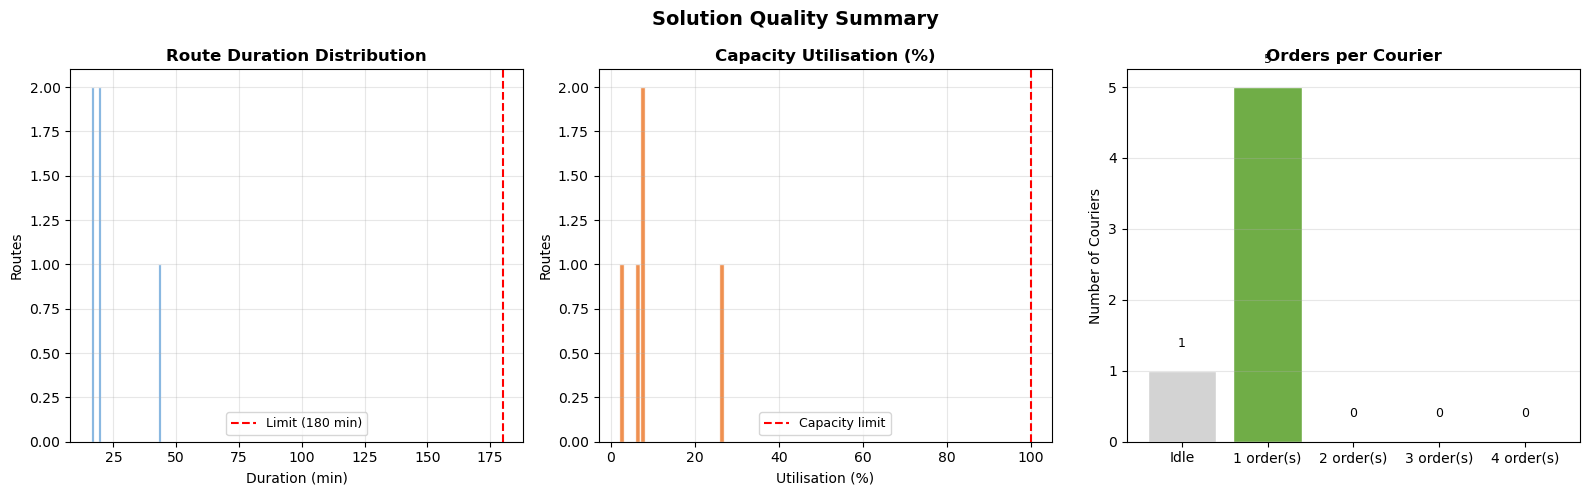

Figure 2 saved: solution_summary.png


In [182]:
# ─── Figure 2: Solution quality summary ──────────────────────────────────────
fig2, axes = plt.subplots(1, 3, figsize=(16, 5))
fig2.suptitle("Solution Quality Summary", fontsize=14, fontweight="bold")

# Gather per-route stats
route_lengths, route_loads, route_order_counts = [], [], []
for cid, orders in best_solution.items():
    if orders:
        dt, dur, seq, ok = evaluate_route(cid, orders, couriers, deliveries, T)
        route_lengths.append(dur)
        route_loads.append(sum(deliveries[o]["capacity"] for o in orders))
        route_order_counts.append(len(orders))

# Subplot A: route duration distribution
axes[0].hist(route_lengths, bins=20, color="#5B9BD5",
             edgecolor="white", alpha=0.85)
axes[0].axvline(MAX_ROUTE_MIN, color="red", ls="--", lw=1.5, label=f"Limit ({MAX_ROUTE_MIN} min)")
axes[0].set_title("Route Duration Distribution", fontweight="bold")
axes[0].set_xlabel("Duration (min)")
axes[0].set_ylabel("Routes")
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# Subplot B: load utilisation
cap_vals = [couriers[cid]["capacity"] for cid in best_solution if best_solution[cid]]
utilisation = [l / c * 100 for l, c in zip(route_loads, cap_vals)]
axes[1].hist(utilisation, bins=20, color="#ED7D31",
             edgecolor="white", alpha=0.85)
axes[1].axvline(100, color="red", ls="--", lw=1.5, label="Capacity limit")
axes[1].set_title("Capacity Utilisation (%)", fontweight="bold")
axes[1].set_xlabel("Utilisation (%)")
axes[1].set_ylabel("Routes")
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

# Subplot C: orders per courier (stacked bar)
counts = [0] * (MAX_STACK + 1)
for c in route_order_counts:
    counts[min(c, MAX_STACK)] += 1
idle = len(couriers) - sum(1 for o in best_solution.values() if o)
bar_vals  = [idle] + counts[1:]
bar_labels = ["Idle"] + [f"{i} order(s)" for i in range(1, MAX_STACK + 1)]
colors     = ["#D3D3D3", "#70AD47", "#9966CC", "#FF9933", "#CC3333"]
bars = axes[2].bar(bar_labels, bar_vals,
                   color=colors[:len(bar_vals)], edgecolor="white")
for bar, val in zip(bars, bar_vals):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 str(val), ha="center", va="bottom", fontsize=9)
axes[2].set_title("Orders per Courier", fontweight="bold")
axes[2].set_ylabel("Number of Couriers")
axes[2].grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("solution_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure 2 saved: solution_summary.png")

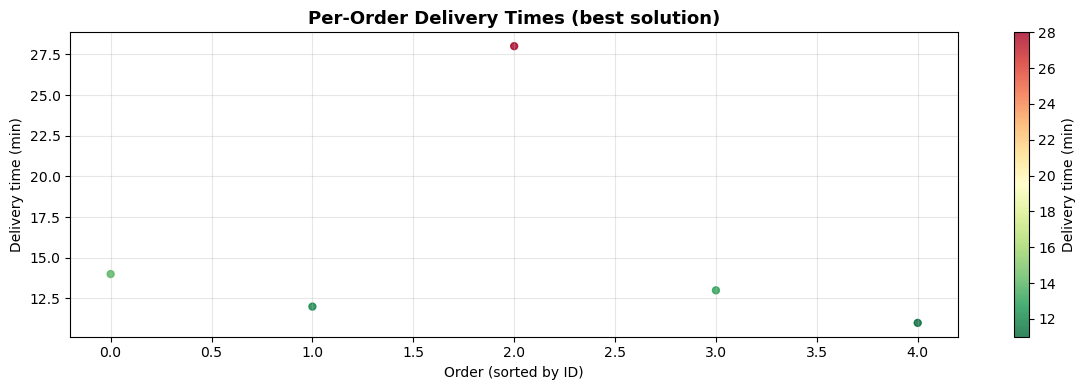

Figure 3 saved: order_delivery_times.png


In [183]:
# ─── Figure 3: per-location delivery-time heatmap ─────────────────────────────
delivery_times_per_order = {}
for cid, orders in best_solution.items():
    if not orders:
        continue
    _, _, seq, _ = evaluate_route(cid, orders, couriers, deliveries, T)
    c   = couriers[cid]
    loc = c["location"]
    t   = 0.0
    load = 0.0
    for oid, typ in seq:
        d = deliveries[oid]
        if typ == "p":
            new_loc = d["pickup_loc"]
            arr     = t + T(loc, new_loc)
            t       = max(arr, d["tw_start"])
            load   += d["capacity"]
        else:
            new_loc = d["dropoff_loc"]
            t      += T(loc, new_loc)
            delivery_times_per_order[oid] = t
            load   -= d["capacity"]
        loc = new_loc

if delivery_times_per_order:
    fig3, ax = plt.subplots(figsize=(12, 4))
    oids_sorted = sorted(delivery_times_per_order)
    dt_vals     = [delivery_times_per_order[o] for o in oids_sorted]
    sc = ax.scatter(range(len(oids_sorted)), dt_vals,
                    c=dt_vals, cmap="RdYlGn_r",
                    s=25, alpha=0.8)
    plt.colorbar(sc, ax=ax, label="Delivery time (min)")
    ax.set_title("Per-Order Delivery Times (best solution)",
                 fontsize=13, fontweight="bold")
    ax.set_xlabel("Order (sorted by ID)")
    ax.set_ylabel("Delivery time (min)")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig("order_delivery_times.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Figure 3 saved: order_delivery_times.png")

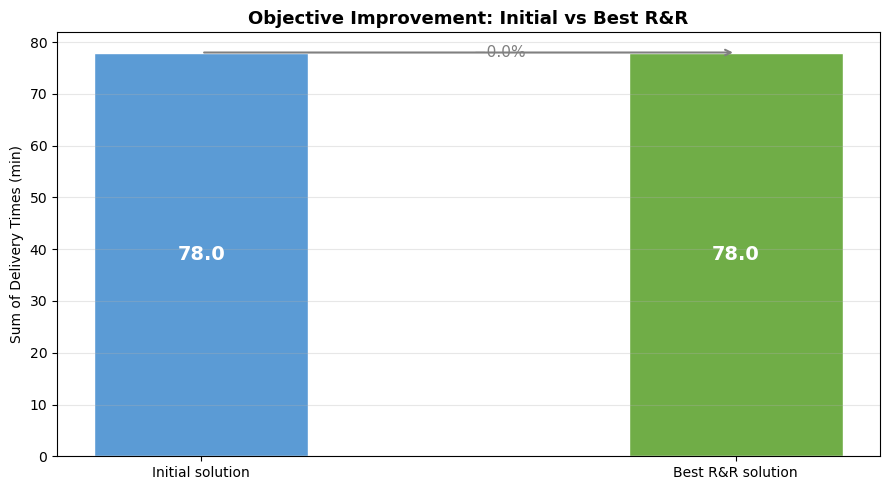

Figure 4 saved: before_after.png


In [184]:
# ─── Figure 4: before-vs-after comparison ─────────────────────────────────────
fig4, ax = plt.subplots(figsize=(9, 5))

categories   = ["Initial solution", "Best R&R solution"]
values       = [init_obj, best_obj]
bar_colors   = ["#5B9BD5", "#70AD47"]
bars = ax.bar(categories, values, color=bar_colors, edgecolor="white",
              width=0.4)

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() * 0.5,
            f"{val:.1f}",
            ha="center", va="center",
            fontsize=14, fontweight="bold", color="white")

improvement_pct = (init_obj - best_obj) / init_obj * 100 if init_obj else 0
ax.annotate("",
            xy=(1, best_obj), xytext=(0, init_obj),
            arrowprops=dict(arrowstyle="->", color="grey", lw=1.5))
ax.text(0.5, (init_obj + best_obj)/2,
        f" −{improvement_pct:.1f}%",
        ha="left", va="center", color="grey", fontsize=11)

ax.set_title("Objective Improvement: Initial vs Best R&R",
             fontsize=13, fontweight="bold")
ax.set_ylabel("Sum of Delivery Times (min)")
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig("before_after.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure 4 saved: before_after.png")

In [185]:
# ─── Summary printout ─────────────────────────────────────────────────────────
print("=" * 55)
print("  VRPPD R&R SOLVER — RESULTS SUMMARY")
print("=" * 55)
print(f"  Instance path     : {INSTANCE_PATH}")
print(f"  Couriers          : {len(couriers)}")
print(f"  Orders            : {len(deliveries)}")
print(f"  Iterations        : {N_ITERATIONS}")
print(f"  Initial T_min     : {init_obj:.2f} min")
print(f"  Best T_min (R&R)  : {best_obj:.2f} min")
improvement_pct = (init_obj - best_obj) / init_obj * 100 if init_obj else 0
print(f"  Improvement       : {improvement_pct:.1f}%")
print(f"  Improvements found: {len(history['improved'])}")
print(f"  Output CSV        : {OUTPUT_CSV}")
print("=" * 55)

  VRPPD R&R SOLVER — RESULTS SUMMARY
  Instance path     : instance12
  Couriers          : 6
  Orders            : 5
  Iterations        : 3000
  Initial T_min     : 78.00 min
  Best T_min (R&R)  : 78.00 min
  Improvement       : 0.0%
  Improvements found: 0
  Output CSV        : result.csv
